# Disease Prediction + Doctor Specialty Recommendation

### Step 1 - Import & Load

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import json
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

folder = "../data/raw/"
files = os.listdir(folder)
print("File yang ada:", files)

File yang ada: ['Disease precaution.csv', 'DiseaseAndSymptoms.csv', 'Disease_Description.csv', 'Doctor_Specialist.csv', 'Doctor_Versus_Disease.csv', 'Specialist.xlsx', 'Symptom_Weights.csv']


In [27]:
dataframes = {}

for f in os.listdir(folder):
    path = os.path.join(folder, f)
    
    if f.endswith('.csv'):
        try:
            dataframes[f] = pd.read_csv(path)
        except UnicodeDecodeError:
            dataframes[f] = pd.read_csv(path, encoding='latin1')
    
    elif f.endswith('.xlsx') or f.endswith('.xls'):
        dataframes[f] = pd.read_excel(path)

for f, df in dataframes.items():
    print(f"{f}: {df.shape}")

Disease precaution.csv: (41, 5)
DiseaseAndSymptoms.csv: (4920, 18)
Disease_Description.csv: (41, 2)
Doctor_Specialist.csv: (19, 1)
Doctor_Versus_Disease.csv: (40, 2)
Specialist.xlsx: (4920, 133)
Symptom_Weights.csv: (130, 2)


### Step 2 - cek file xlsx

In [28]:
xlsx_files = [f for f in dataframes if f.endswith('.xlsx')]
for f in xlsx_files:
    print(f"\n=== {f} ===")
    print(dataframes[f].shape)
    print(dataframes[f].columns.tolist())
    print(dataframes[f].head())


=== Specialist.xlsx ===
(4920, 133)
['Unnamed: 0', 'itching', ' skin_rash', ' nodal_skin_eruptions', ' dischromic _patches', ' continuous_sneezing', ' shivering', ' chills', ' watering_from_eyes', ' stomach_pain', ' acidity', ' ulcers_on_tongue', ' vomiting', ' cough', ' chest_pain', ' yellowish_skin', ' nausea', ' loss_of_appetite', ' abdominal_pain', ' yellowing_of_eyes', ' burning_micturition', ' spotting_ urination', ' passage_of_gases', ' internal_itching', ' indigestion', ' muscle_wasting', ' patches_in_throat', ' high_fever', ' extra_marital_contacts', ' fatigue', ' weight_loss', ' restlessness', ' lethargy', ' irregular_sugar_level', ' blurred_and_distorted_vision', ' obesity', ' excessive_hunger', ' increased_appetite', ' polyuria', ' sunken_eyes', ' dehydration', ' diarrhoea', ' breathlessness', ' family_history', ' mucoid_sputum', ' headache', ' dizziness', ' loss_of_balance', ' lack_of_concentration', ' stiff_neck', ' depression', ' irritability', ' visual_disturbances', '

### Step 3 - EDA Data

In [29]:
df_raw = dataframes["DiseaseAndSymptoms.csv"].copy()
df_raw.info()
print("\nMissing value per kolom:")
print(df_raw.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB

Missing value per kolom:
Disease          0
Sympt

In [30]:
print("Jumlah penyakit unik:", df_raw['Disease'].nunique())
df_raw['Disease'].value_counts()

Jumlah penyakit unik: 41


Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B                                120
Hepat

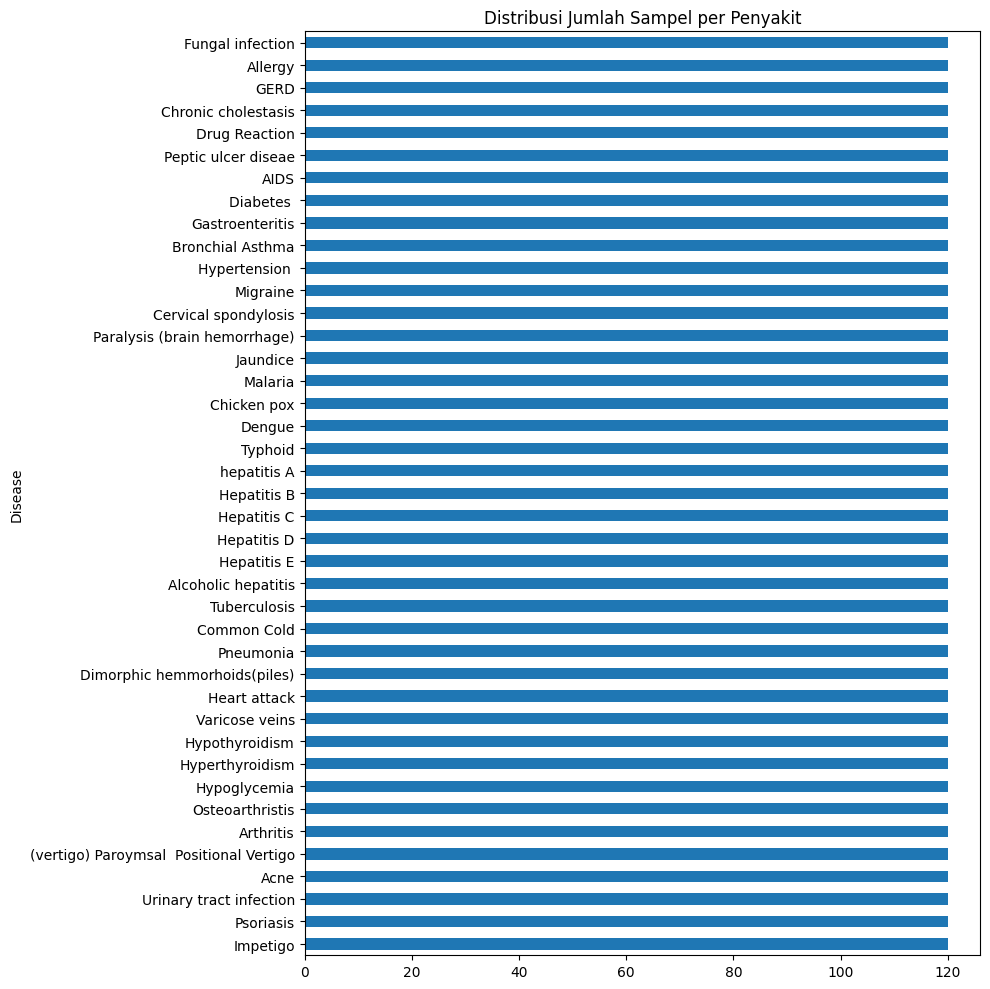

In [31]:
plt.figure(figsize=(10,10))
df_raw['Disease'].value_counts().plot(kind='barh')
plt.title("Distribusi Jumlah Sampel per Penyakit")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
counts = df_raw['Disease'].value_counts()
print("Rasio sampel terbanyak vs tersedikit:", counts.max() / counts.min())

Rasio sampel terbanyak vs tersedikit: 1.0


### Step 4 - One Hot Encoding Gejala

In [33]:
symptom_cols = [c for c in df_raw.columns if 'Symptom' in c]
print("Kolom gejala:", symptom_cols)

for col in symptom_cols:
    df_raw[col] = df_raw[col].astype(str).str.strip().str.lower()
    df_raw[col] = df_raw[col].replace('nan', np.nan)

Kolom gejala: ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']


In [34]:
all_symptoms = pd.unique(df_raw[symptom_cols].values.ravel())
all_symptoms = sorted([s for s in all_symptoms if pd.notna(s)])
print("Jumlah gejala unik:", len(all_symptoms))
print(all_symptoms[:20])

Jumlah gejala unik: 131
['abdominal_pain', 'abnormal_menstruation', 'acidity', 'acute_liver_failure', 'altered_sensorium', 'anxiety', 'back_pain', 'belly_pain', 'blackheads', 'bladder_discomfort', 'blister', 'blood_in_sputum', 'bloody_stool', 'blurred_and_distorted_vision', 'breathlessness', 'brittle_nails', 'bruising', 'burning_micturition', 'chest_pain', 'chills']


In [35]:
for symptom in all_symptoms:
    df_raw[symptom] = df_raw[symptom_cols].apply(
        lambda row: symptom in row.values, axis=1
    ).astype(int)

df_final = df_raw.drop(columns=symptom_cols)
df_final = df_final.drop_duplicates()
print("Shape setelah encoding & hapus duplikat:", df_final.shape)
df_final.head()

Shape setelah encoding & hapus duplikat: (304, 132)


,Disease,abdominal_pain,abnormal_menstruation,acidity,acute_liver_failure,altered_sensorium,anxiety,back_pain,belly_pain,blackheads,bladder_discomfort,blister,blood_in_sputum,bloody_stool,blurred_and_distorted_vision,breathlessness,brittle_nails,bruising,burning_micturition,chest_pain,chills,cold_hands_and_feets,coma,congestion,constipation,continuous_feel_of_urine,continuous_sneezing,cough,cramps,dark_urine,dehydration,depression,diarrhoea,dischromic _patches,distention_of_abdomen,dizziness,drying_and_tingling_lips,enlarged_thyroid,excessive_hunger,extra_marital_contacts,family_history,fast_heart_rate,fatigue,fluid_overload,foul_smell_of urine,headache,high_fever,hip_joint_pain,history_of_alcohol_consumption,increased_appetite,indigestion,inflammatory_nails,internal_itching,irregular_sugar_level,irritability,irritation_in_anus,itching,joint_pain,knee_pain,lack_of_concentration,lethargy,loss_of_appetite,loss_of_balance,loss_of_smell,malaise,mild_fever,mood_swings,movement_stiffness,mucoid_sputum,muscle_pain,muscle_wasting,muscle_weakness,nausea,neck_pain,nodal_skin_eruptions,obesity,pain_behind_the_eyes,pain_during_bowel_movements,pain_in_anal_region,painful_walking,palpitations,passage_of_gases,patches_in_throat,phlegm,polyuria,prominent_veins_on_calf,puffy_face_and_eyes,pus_filled_pimples,receiving_blood_transfusion,receiving_unsterile_injections,red_sore_around_nose,red_spots_over_body,redness_of_eyes,restlessness,runny_nose,rusty_sputum,scurring,shivering,silver_like_dusting,sinus_pressure,skin_peeling,skin_rash,slurred_speech,small_dents_in_nails,spinning_movements,spotting_ urination,stiff_neck,stomach_bleeding,stomach_pain,sunken_eyes,sweating,swelled_lymph_nodes,swelling_joints,swelling_of_stomach,swollen_blood_vessels,swollen_extremeties,swollen_legs,throat_irritation,toxic_look_(typhos),ulcers_on_tongue,unsteadiness,visual_disturbances,vomiting,watering_from_eyes,weakness_in_limbs,weakness_of_one_body_side,weight_gain,weight_loss,yellow_crust_ooze,yellow_urine,yellowing_of_eyes,yellowish_skin
0,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,Fungal infection,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [36]:
os.makedirs("../data/processed", exist_ok=True)
df_final.to_csv("../data/processed/disease_symptoms_encoded.csv", index=False)

### Step 5 - X,Y Split & Train-Test Split

In [37]:
X = df_final.drop(columns=['Disease'])
y = df_final['Disease']

print("Jumlah fitur (gejala):", X.shape[1])
print("Jumlah kelas (penyakit):", y.nunique())

Jumlah fitur (gejala): 131
Jumlah kelas (penyakit): 41


In [38]:
class_counts = y.value_counts()
print("Kelas dengan sampel < 2:")
print(class_counts[class_counts < 2])

valid_classes = class_counts[class_counts >= 2].index
df_final = df_final[df_final['Disease'].isin(valid_classes)]
X = df_final.drop(columns=['Disease'])
y = df_final['Disease']

Kelas dengan sampel < 2:
Series([], Name: count, dtype: int64)


In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

os.makedirs("../models", exist_ok=True)
joblib.dump(le, "../models/label_encoder.pkl")

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (243, 131) Test: (61, 131)
